# arc3-q27b

5.49 harness (Son's Flash-Next replica bundle) with the serving stack swapped to Tufa's 2026-09-01 public recipe: Qwen3.8-27B-FP8 on vLLM 0.19, max-model-len 65536, no MTP / FP8 KV / async. Only cell 8 (serving) and the validation cell change; the harness dataset is byte-identical.

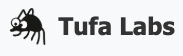

## 1. Environment and submission mode

Detect whether this is a real competition rerun (which minimises diagnostics), set the
framework's environment flags, and put the CUDA libraries on the linker path.

In [ ]:
import json
import os
import pickle
import subprocess
import sys
import sysconfig
import time
from datetime import datetime, timedelta
from pathlib import Path
from urllib.request import urlopen

# True only inside a real competition rerun; switches diagnostics + soft deadline.
TRUE_SUBMISSION = os.environ.get("KAGGLE_IS_COMPETITION_RERUN", "").strip().lower() in {"1", "true"}
NOTEBOOK_START_EPOCH = time.time()

# Non-interactive matplotlib backend: diagnostics render plots with no display attached.
os.environ["MPLBACKEND"] = "Agg"
# Marks the run as a (real or emulated) submission so the framework + solver can adjust.
os.environ["TAAF_RUN_AS_SUBMISSION"] = "1" if TRUE_SUBMISSION else "0"
# In submission, disable the periodic JSON/HTML diagnostics writes and per-frame logging.
os.environ["TAAF_MINIMAL_DIAGNOSTICS"] = "1" if TRUE_SUBMISSION else "0"
# Pin arc_agi's cached level_reset_only before its client is built (RESET keeps the level).
os.environ["ONLY_RESET_LEVELS"] = "true"

# Prepend the CUDA toolkit to the linker path (it is off it on Kaggle GPU images) so the
# solver's GPU libraries (e.g. vllm / torch) can link against libcuda.
cuda_library_path = "/usr/local/nvidia/lib64"
os.environ["LIBRARY_PATH"] = os.pathsep.join(
    entry for entry in [cuda_library_path, *os.environ.get("LIBRARY_PATH", "").split(os.pathsep)] if entry
)

# Everything the run produces is written here.
WORKING_DIR = Path("/kaggle/working")
WORKING_DIR.mkdir(parents=True, exist_ok=True)
print(f"taaf.kaggle: TRUE_SUBMISSION={TRUE_SUBMISSION}")

## 2. Install the ARC runtime

Install `arc-agi` from the offline competition wheelhouse (the Kaggle submission environment
has no internet).

In [ ]:
# 09-01: Kaggle 比赛数据挂载偶发抽风(缺目录即装包秒死), 等它就绪最多10分钟
import time as _t
_wheels = Path("/kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels")
for _i in range(18):
    if _wheels.is_dir():
        print(f"competition wheels mounted after {_i*10}s")
        break
    _t.sleep(10)
else:
    raise RuntimeError(f"competition data never mounted: {_wheels}")
# Install the ARC runtime from the bundled competition wheels.
# Quiet: stdout is discarded; stderr (and a non-zero exit) still surface real failures.
subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--no-index",
        "--no-warn-conflicts",
        "--disable-pip-version-check",
        "--find-links",
        "/kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels",
        "arc-agi",
    ],
    stdout=subprocess.DEVNULL,
)

## 3. Locate the source bundle

Find the uploaded TAAF source dataset by its marker file, and record where Kaggle mounted
every attached input so setup commands and the solver can find them.

In [ ]:
# Kaggle inputs attached to this notebook, plus bookkeeping paths used below.
DATASET_SOURCES = ["jinbowang1/arc3-fnrep-source", "driessmit1/arc3-vllm-h100-wheelhouse-v3", "jakobbrggen/qwen3-8-27b-fp8-hf-snapshot"]
KERNEL_SOURCES = []
DATASET_BUNDLE_MARKER = "taaf-kaggle-bundle.json"
SETUP_ENV_PATH = WORKING_DIR / "taaf_setup_env.json"


# Locate the source dataset by its marker file rather than a fixed mount path.
def _find_bundle_dir() -> Path:
    markers = sorted(Path("/kaggle/input").rglob(DATASET_BUNDLE_MARKER))
    his = [m for m in markers if "arc3-fnrep-source" in str(m)]
    if his:
        return his[0].parent
    raise RuntimeError(f"fnrep bundle marker not found; saw: {markers}")


# Kaggle mounts a dataset at /kaggle/input/<slug> or /kaggle/input/datasets/<owner>/<slug>
# (depending on owner / slug collisions), so probe both and use whichever exists. Utility
# scripts mount under /kaggle/usr/lib/notebooks/<owner>/<slug>.
def _dataset_mount_candidates(ref: str) -> list[Path]:
    owner, slug = ref.split("/", 1)
    return [Path("/kaggle/input") / slug, Path("/kaggle/input/datasets") / owner / slug]


def _kernel_mount_candidates(ref: str) -> list[Path]:
    owner, slug = ref.split("/", 1)
    return [Path("/kaggle/usr/lib/notebooks") / owner / slug]


def _first_existing(candidates: list[Path]) -> Path | None:
    return next((c for c in candidates if c.exists()), None)


BUNDLE_DIR = _find_bundle_dir()
print(f"taaf.kaggle: source bundle = {BUNDLE_DIR}")

# Map each attached input to where Kaggle actually mounted it (the source bundle is index 0).
kaggle_input_paths: dict[str, str] = {}
for i, ref in enumerate(DATASET_SOURCES):
    candidates = _dataset_mount_candidates(ref)
    resolved = BUNDLE_DIR if i == 0 else _first_existing(candidates)
    kaggle_input_paths[ref] = str(resolved or candidates[0])
for ref in KERNEL_SOURCES:
    candidates = _kernel_mount_candidates(ref)
    kaggle_input_paths[ref] = str(_first_existing(candidates) or candidates[0])

# Published to setup commands and the solver via the environment:
setup_env = {
    # JSON {ref: mount_path} so they can locate every attached dataset / utility script.
    "TAAF_KAGGLE_INPUT_PATHS": json.dumps(kaggle_input_paths, sort_keys=True),
    # The attached dataset refs in order (index 0 is this source bundle).
    "TAAF_KAGGLE_DATASET_SOURCES": json.dumps(DATASET_SOURCES),
    # The attached utility-script / kernel refs.
    "TAAF_KAGGLE_KERNEL_SOURCES": json.dumps(KERNEL_SOURCES),
}
os.environ.update(setup_env)
SETUP_ENV_PATH.write_text(json.dumps(setup_env, indent=2, sort_keys=True) + "\n")
print(f"taaf.kaggle: input paths = {setup_env['TAAF_KAGGLE_INPUT_PATHS']}")

## 4. Import the bundled source and run solver setup

Put the snapshotted repositories on the path (this process and any child processes), then run
the solver's setup commands â€” installing wheels, fetching model weights, and so on.

In [ ]:
# Each bundled repo exposes its importable tree at <repo>/src or <repo>.
def _source_path_entries(bundle_dir: Path) -> list:
    entries = []
    for repo in sorted((bundle_dir / "src").iterdir(), reverse=True):
        for candidate in (repo / "src", repo):
            if candidate.is_dir():
                entries.append(candidate)
    return entries


# Environment handed to each setup command (paths + any keys it has persisted).
def _command_env() -> dict:
    env = os.environ.copy()
    env["PYTHON"] = sys.executable
    env["TAAF_KAGGLE_BUNDLE_DIR"] = str(BUNDLE_DIR)
    env["TAAF_KAGGLE_WORKING_DIR"] = str(WORKING_DIR)
    env["TAAF_KAGGLE_SETUP_ENV"] = str(SETUP_ENV_PATH)
    env.update({str(k): str(v) for k, v in json.loads(SETUP_ENV_PATH.read_text()).items()})
    return env


# Make the bundled repos importable here (sys.path) and in child processes (.pth).
source_entries = _source_path_entries(BUNDLE_DIR)
for entry in source_entries:
    sys.path.insert(0, str(entry))
pth_path = Path(sysconfig.get_paths()["purelib"]) / "taaf_kaggle_sources.pth"
pth_path.write_text("".join(f"{entry}\n" for entry in source_entries))
print(f"taaf.kaggle: wrote {pth_path} ({len(source_entries)} source roots)")


# ---- 09-18 Q27B: 伺服栈换成 Tufa 09-01 公开配方 (vLLM 0.19 wheelhouse + Qwen3.8-27B-FP8, 64k, 无 MTP/FP8KV/async) ----
# bundle 里 Son 的 kaggle_flashnext_preconverted_setup.py 不再执行; 下面这段脚本逐字来自
# jakobbrggen/taaf-kaggle-source v27 的 setup_commands.json, 它会把 LOCAL_ANALYZER_* 写进 TAAF_KAGGLE_SETUP_ENV。
Q27B_SETUP = r"""
import json
import os
import shutil
import subprocess
import sys
import time
import urllib.request
from pathlib import Path

WHEELHOUSE_OWNER = 'driessmit1'
WHEELHOUSE_SLUG = 'arc3-vllm-h100-wheelhouse-v3'
MODEL_OWNER = 'jakobbrggen'
MODEL_SLUG = 'qwen3-8-27b-fp8-hf-snapshot'
SERVED_MODEL_NAME = 'Qwen/Qwen3.8-27B-FP8'
VLLM_HOST = '127.0.0.1'
VLLM_PORT = 1234
VLLM_BASE_URL = f'http://{VLLM_HOST}:{VLLM_PORT}/v1'
VLLM_MAX_MODEL_LEN = 65536
ANALYZER_CONTEXT_WINDOW = 32768
VLLM_TENSOR_PARALLEL_SIZE = 1
WORKING_DIR = Path(os.environ['TAAF_KAGGLE_WORKING_DIR'])
SITE_PACKAGES = WORKING_DIR / 'vllm-site-packages'
VLLM_SERVER_LOG = WORKING_DIR / 'vllm-openai-server.log'
VLLM_SERVER_PID = WORKING_DIR / 'vllm-openai-server.pid'
INSTALL_STAMP = SITE_PACKAGES / f'.{WHEELHOUSE_SLUG}'
STAMP_TEXT = 'vllm==0.19.0 torch==2.10.0 flashinfer==0.6.6\n'

GPU_NAME_PATTERNS = {'rtx-pro-6000': ('rtx pro 6000',), 'h100': ('h100',), 'l4': ('l4',)}


def taaf_kaggle_input_paths() -> dict[str, Path]:
    raw = os.getenv('TAAF_KAGGLE_INPUT_PATHS', '').strip()
    if not raw:
        return {}
    data = json.loads(raw)
    if not isinstance(data, dict):
        raise RuntimeError('TAAF_KAGGLE_INPUT_PATHS must contain a JSON object.')
    return {str(ref): Path(str(path)) for ref, path in data.items()}


def resolve_kaggle_dataset_path(owner: str, slug: str) -> Path:
    mapped = taaf_kaggle_input_paths().get(f'{owner}/{slug}')
    if mapped is not None:
        return mapped
    for dataset_path in (Path('/kaggle/input') / slug, Path('/kaggle/input/datasets') / owner / slug):
        if dataset_path.exists():
            return dataset_path
    return Path('/kaggle/input') / slug


WHEELHOUSE = resolve_kaggle_dataset_path(WHEELHOUSE_OWNER, WHEELHOUSE_SLUG)
MODEL_PATH = resolve_kaggle_dataset_path(MODEL_OWNER, MODEL_SLUG)


def assert_expected_cuda_gpu() -> None:
    if not Path('/kaggle/input').exists():
        return
    assert shutil.which('nvidia-smi'), 'CUDA GPU check failed: nvidia-smi is not available.'
    result = subprocess.run(['nvidia-smi', '--query-gpu=name', '--format=csv,noheader'], capture_output=True, text=True)
    assert result.returncode == 0, f'nvidia-smi failed: {result.stderr.strip()}'
    gpu_names = [line.strip() for line in result.stdout.splitlines() if line.strip()]
    assert gpu_names, 'nvidia-smi did not report any CUDA GPUs.'
    expected_gpu_type = os.getenv('KAGGLE_GPU_TYPE', 'rtx-pro-6000').strip().lower()
    expected_count = os.getenv('KAGGLE_GPU_COUNT', '1')
    if expected_count.isdigit():
        assert len(gpu_names) == int(expected_count), f'Expected {expected_count} CUDA GPU(s), found {gpu_names}'
    patterns = GPU_NAME_PATTERNS.get(expected_gpu_type, (expected_gpu_type.replace('-', ' '),))
    mismatched = [name for name in gpu_names if not any(pattern in name.lower() for pattern in patterns)]
    assert not mismatched, f'Expected GPU type {expected_gpu_type!r}, found {gpu_names}'
    print(f'CUDA GPU check passed for {expected_gpu_type} x{expected_count}: {gpu_names}', flush=True)


def vllm_env() -> dict[str, str]:
    env = os.environ.copy()
    existing = env.get('PYTHONPATH', '')
    env['PYTHONPATH'] = str(SITE_PACKAGES) if not existing else f'{SITE_PACKAGES}{os.pathsep}{existing}'
    env.update(
        {
            'USE_TF': '0',
            'TRANSFORMERS_NO_TF': '1',
            'TRANSFORMERS_NO_TORCHVISION': '1',
            'VLLM_NO_USAGE_STATS': '1',
        }
    )
    return env


def cached_install_is_usable() -> bool:
    if not INSTALL_STAMP.exists() or INSTALL_STAMP.read_text(encoding='utf-8') != STAMP_TEXT:
        return False
    result = subprocess.run(
        [sys.executable, '-c', "import vllm, torch; print(f'Cached vLLM {vllm.__version__}, torch {torch.__version__}')"],
        env=vllm_env(),
        text=True,
    )
    return result.returncode == 0


def install_vllm_wheelhouse() -> None:
    requirements = WHEELHOUSE / 'requirements.lock'
    if not requirements.exists():
        raise FileNotFoundError(f'Missing wheelhouse lock file: {requirements}')
    if cached_install_is_usable():
        print(f'Using cached vLLM target install at {SITE_PACKAGES}', flush=True)
        return
    shutil.rmtree(SITE_PACKAGES, ignore_errors=True)
    SITE_PACKAGES.mkdir(parents=True, exist_ok=True)
    cmd = [
        sys.executable,
        '-m',
        'pip',
        'install',
        '--no-index',
        '--find-links',
        str(WHEELHOUSE),
        '--requirement',
        str(requirements),
        '--target',
        str(SITE_PACKAGES),
        '--upgrade',
        '--ignore-installed',
        '--only-binary',
        ':all:',
        '--no-compile',
        '--disable-pip-version-check',
        '--no-warn-conflicts',
    ]
    print('Installing vLLM wheelhouse into', SITE_PACKAGES, flush=True)
    subprocess.run(cmd, check=True)
    INSTALL_STAMP.write_text(STAMP_TEXT, encoding='utf-8')


def request_json(url: str, payload: dict | None = None, timeout: int = 30) -> dict:
    data = None if payload is None else json.dumps(payload).encode('utf-8')
    request = urllib.request.Request(url, data=data, headers={'Content-Type': 'application/json'})
    with urllib.request.urlopen(request, timeout=timeout) as response:
        return json.loads(response.read().decode('utf-8'))


def tail_server_log(lines: int = 80) -> str:
    if not VLLM_SERVER_LOG.exists():
        return ''
    return '\n'.join(VLLM_SERVER_LOG.read_text(encoding='utf-8', errors='replace').splitlines()[-lines:])


def wait_for_vllm_server(timeout_seconds: int = 900) -> None:
    deadline = time.monotonic() + timeout_seconds
    url = f'{VLLM_BASE_URL}/models'
    while time.monotonic() < deadline:
        if VLLM_SERVER_PID.exists():
            try:
                os.kill(int(VLLM_SERVER_PID.read_text().strip()), 0)
            except OSError as exc:
                raise RuntimeError(f'vLLM server process is not alive: {exc}\n{tail_server_log()}') from exc
        try:
            models = request_json(url, timeout=5)
            print('vLLM server ready:', models, flush=True)
            return
        except Exception:
            time.sleep(5)
    raise TimeoutError(f'Timed out waiting for vLLM server at {url}.\nLast server log lines:\n{tail_server_log()}')


def start_vllm_server() -> None:
    install_vllm_wheelhouse()
    VLLM_SERVER_LOG.parent.mkdir(parents=True, exist_ok=True)
    VLLM_SERVER_PID.unlink(missing_ok=True)
    log_handle = VLLM_SERVER_LOG.open('w', encoding='utf-8')
    cmd = [
        sys.executable,
        '-m',
        'vllm.entrypoints.openai.api_server',
        '--model',
        str(MODEL_PATH),
        '--served-model-name',
        SERVED_MODEL_NAME,
        '--host',
        VLLM_HOST,
        '--port',
        str(VLLM_PORT),
        '--tensor-parallel-size',
        str(VLLM_TENSOR_PARALLEL_SIZE),
        '--enable-auto-tool-choice',
        '--tool-call-parser',
        'qwen3_coder',
        '--generation-config',
        'vllm',
        '--enable-prefix-caching',
        '--default-chat-template-kwargs',
        '{"preserve_thinking": true}',
        '--reasoning-parser',
        'qwen3',
        '--max-model-len',
        str(VLLM_MAX_MODEL_LEN),
    ]
    print('Starting vLLM OpenAI server:', ' '.join(cmd), flush=True)
    process = subprocess.Popen(cmd, env=vllm_env(), stdout=log_handle, stderr=subprocess.STDOUT, text=True)
    VLLM_SERVER_PID.write_text(str(process.pid), encoding='utf-8')
    wait_for_vllm_server()


def run_vllm_api_smoke_test() -> None:
    payload = {
        'model': SERVED_MODEL_NAME,
        'messages': [{'role': 'user', 'content': 'Answer in one short sentence: what is 2 + 2?'}],
        'temperature': 0.0,
        'max_tokens': 96,
        'chat_template_kwargs': {'enable_thinking': False},
    }
    response = request_json(f'{VLLM_BASE_URL}/chat/completions', payload=payload, timeout=120)
    generated = response['choices'][0]['message'].get('content', '').strip()
    print('\n' + '=' * 88, flush=True)
    print('VLLM OPENAI SERVER QWEN SMOKE TEST REAL MODEL OUTPUT', flush=True)
    print('Generated:', generated, flush=True)
    print('=' * 88 + '\n', flush=True)


print(f'vLLM wheelhouse path: {WHEELHOUSE}', flush=True)
print(f'Qwen model path: {MODEL_PATH}', flush=True)
assert_expected_cuda_gpu()
missing = [str(path) for path in (WHEELHOUSE, MODEL_PATH) if not path.exists()]
if missing:
    raise FileNotFoundError('Missing attached dataset path(s): ' + ', '.join(missing))
start_vllm_server()
run_vllm_api_smoke_test()
setup_env = {
    'USE_TF': '0',
    'TRANSFORMERS_NO_TF': '1',
    'TRANSFORMERS_NO_TORCHVISION': '1',
    'VLLM_NO_USAGE_STATS': '1',
    'PYTHONPATH': str(SITE_PACKAGES) + os.pathsep + os.environ.get('PYTHONPATH', ''),
    'LOCAL_ANALYZER_BASE_URL': VLLM_BASE_URL,
    'OPENAI_BASE_URL': VLLM_BASE_URL,
    'LOCAL_ANALYZER_PROVIDER': 'vllm',
    'OPENAI_PROVIDER': 'vllm',
    'LOCAL_ANALYZER_MODEL_ID': SERVED_MODEL_NAME,
    'INFERENCE_ANALYZER_MODEL': SERVED_MODEL_NAME,
    'LOCAL_ANALYZER_APP_NAME': 'ARC3 Agent Harness',
    'LOCAL_ANALYZER_CONTEXT_WINDOW': str(ANALYZER_CONTEXT_WINDOW),
    'LOCAL_ANALYZER_MAX_OUTPUT': '0',
    'LOCAL_ANALYZER_TOOL_STEPS': '0',
    'LOCAL_ANALYZER_TOOL_TIMEOUT': '30',
    'LOCAL_ANALYZER_TOOL_OUTPUT_TOKENS': '1024',
    'LOCAL_ANALYZER_YIELD_SECONDS': '60',
    'LOCAL_ANALYZER_TEMPERATURE': '0.6',
    'LOCAL_ANALYZER_TOP_P': '0.95',
    'LOCAL_ANALYZER_TOP_K': '20',
    'LOCAL_ANALYZER_ENABLE_THINKING': 'true',
    'MULTIMODAL_CONTEXT': 'current_grid',
    'MULTIMODAL_UPSCALE': '8',
    'MULTIMODAL_GRID_LINES': '1',
}
setup_env_path = Path(os.environ['TAAF_KAGGLE_SETUP_ENV'])
existing_setup_env = {}
if setup_env_path.exists():
    existing_setup_env = json.loads(setup_env_path.read_text(encoding='utf-8'))
    if not isinstance(existing_setup_env, dict):
        raise RuntimeError('TAAF_KAGGLE_SETUP_ENV must contain a JSON object.')
existing_setup_env.update(setup_env)
setup_env_path.write_text(json.dumps(existing_setup_env, indent=2), encoding='utf-8')
"""

env = _command_env()
print("Q27B: starting Tufa serving stack (Qwen3.8-27B-FP8 on vLLM 0.19, max-model-len 65536)", flush=True)
subprocess.run([sys.executable, "-"], input=Q27B_SETUP, text=True, check=True, cwd=WORKING_DIR, env=env)
env = _command_env()
os.environ.update(env)

# Honour any PYTHONPATH a setup command exported.
for entry in reversed([e for e in os.environ.get("PYTHONPATH", "").split(os.pathsep) if e]):
    if entry not in sys.path:
        sys.path.insert(0, entry)

# V31 看门狗只认 Flash-Next 的 provenance/MTP 参数, 09-14 查实在这条栈上必失败; Tufa 自己也不带看门狗。留空壳给 cell 14。
import urllib.request as _q27b_urllib

_Q27B_URL = os.environ.get("LOCAL_ANALYZER_BASE_URL", "http://127.0.0.1:1234/v1").rstrip("/")


def _q27b_healthy(timeout: float = 4.0) -> bool:
    try:
        with _q27b_urllib.urlopen(f"{_Q27B_URL}/models", timeout=timeout) as response:
            return 200 <= int(response.status) < 500
    except Exception:
        return False


def _v31_start_watchdog(solver) -> None:
    print("Q27B: no watchdog (Tufa serving stack runs bare).", flush=True)


def _v31_stop_watchdog() -> None:
    pass


if not _q27b_healthy(10):
    raise RuntimeError("Q27B preflight: local vLLM API is not healthy.")
print("Q27B preflight: local vLLM API healthy.", flush=True)
print("Q27B analyzer model:", os.environ.get("INFERENCE_ANALYZER_MODEL"),
      "context:", os.environ.get("LOCAL_ANALYZER_CONTEXT_WINDOW"),
      "upscale:", os.environ.get("MULTIMODAL_UPSCALE"),
      "temperature:", os.environ.get("LOCAL_ANALYZER_TEMPERATURE"), flush=True)


## 5. Load the benchmark

Unpickle the deployment target and the benchmark, stamping the real submission state onto the
target and pointing the benchmark's outputs at the Kaggle working directory.

In [ ]:
# Restore the deployment target and record the real submission state on it.
with open(BUNDLE_DIR / "deploy_target.pkl", "rb") as file:
    target = pickle.load(file)
target.actual_run_as_submission = TRUE_SUBMISSION
target.is_competition_rerun = TRUE_SUBMISSION

# Restore the benchmark and point its outputs at the Kaggle working dir.
with open(BUNDLE_DIR / "benchmark_initial.pkl", "rb") as file:
    bm = pickle.load(file)
bm.job_dir = WORKING_DIR

## 6. Customization hook

Optional: tweak `bm`, `bm.games`, or `bm.solver` here before the run starts â€” the safe place
for one-off experiments once the deployed bundle has loaded.

In [ ]:
# V31 keeps the V22 gameplay/prompt/tool policy unchanged.
bm.solver.save_request_logs = False
print("V31 concurrency:", getattr(bm.solver, "concurrency", None))
print("V31 analyzer_timeout:", getattr(bm.solver, "analyzer_timeout", None))
print("V31 save_request_logs:", getattr(bm.solver, "save_request_logs", None))


## 7. Run the benchmark

In a real competition rerun (`KAGGLE_IS_COMPETITION_RERUN`), wait for the Kaggle gateway and
play the **live competition Arcade**. Otherwise â€” an interactive "Save & Run" â€” play the
competition's **bundled environment files offline**, with no gateway required, so the notebook
runs end-to-end without a submission. Teardown commands run afterward even if the run raises.

In [ ]:
# Build the live competition game list from the gateway's available environments.
def _competition_games():
    import arc_agi

    import taaf.game_api

    spec = taaf.game_api.ArcadeSpec(
        operation_mode=arc_agi.OperationMode.COMPETITION,
        arc_base_url=os.environ["ARC_BASE_URL"],
        environments_dir="",
    )
    arcade = arc_agi.Arcade(
        operation_mode=arc_agi.OperationMode.COMPETITION,
        arc_base_url=spec.arc_base_url,
        environments_dir="",
    )
    game_ids = [env_info.game_id for env_info in arcade.available_environments]
    if not game_ids:
        raise RuntimeError("Competition Arcade exposed zero environments.")
    return [taaf.game_api.GameAPI(env_name=game_id, arcade_spec=spec) for game_id in game_ids]


# Build the offline game list from the competition's bundled environment files.
def _offline_games(env_dir: str):
    import arc_agi

    import taaf.game_api

    spec = taaf.game_api.ArcadeSpec(operation_mode=arc_agi.OperationMode.OFFLINE, environments_dir=env_dir)
    arcade = arc_agi.Arcade(operation_mode=arc_agi.OperationMode.OFFLINE, environments_dir=env_dir)
    game_ids = [env_info.game_id for env_info in arcade.available_environments]
    if not game_ids:
        raise RuntimeError(f"No offline environments found under {env_dir}.")
    return [taaf.game_api.GameAPI(env_name=game_id, arcade_spec=spec) for game_id in game_ids]


# The gateway can take a while to come up; poll until it answers.
def _wait_for_gateway(base_url: str, timeout_s: float = 600.0) -> None:
    deadline = time.monotonic() + timeout_s
    last_error = ""
    while time.monotonic() < deadline:
        try:
            with urlopen(f"{base_url}api/games", timeout=10) as response:
                if response.status < 500:
                    return
        except Exception as exc:
            last_error = repr(exc)
        time.sleep(5)
    raise RuntimeError(f"Kaggle gateway did not become ready: {last_error}")


# Print the run preamble and persist the launcher's git status for diagnostics.
print((BUNDLE_DIR / "preamble.txt").read_text())
(WORKING_DIR / "git_status.txt").write_text((BUNDLE_DIR / "git_status.txt").read_text())

# arc_agi reads RECORDINGS_DIR and ARC_API_KEY from env (ArcadeSpec carries neither); operation
# mode, environments dir, and base url are all passed explicitly via the spec, so no env is needed.
os.environ.setdefault("RECORDINGS_DIR", str(WORKING_DIR / "server_recording"))

if TRUE_SUBMISSION:
    # Real submission: play the live competition Arcade served by the Kaggle gateway.
    os.environ.setdefault("ARC_API_KEY", "test-key-123")
    os.environ.setdefault("ARC_BASE_URL", "http://gateway:8001/")
    # The gateway boots asynchronously; wait before swapping in its game list.
    _wait_for_gateway(os.environ["ARC_BASE_URL"])
    bm.games = _competition_games()
else:
    # Interactive run: play the bundled competition environments offline (no gateway).
    # The competition's environment files ship alongside the wheelhouse in the competition dataset.
    competition_env_files = str(Path("/kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels").parent / "environment_files")
    bm.games = _offline_games(competition_env_files)

bm.n_passes = 1
bm.game_weights = None

# Outside a real submission, stop ~10 min before the wall-clock budget for a graceful exit.
soft_end = None
if not TRUE_SUBMISSION:
    budget = float(getattr(target, "max_runtime_s", 0.0) or 0.0)
    if budget > 0:
        soft_end = datetime.fromtimestamp(NOTEBOOK_START_EPOCH) + timedelta(seconds=budget - min(600.0, budget / 2))

# Play the benchmark under the server watchdog.
_v31_start_watchdog(bm.solver)
try:
    await bm.run(
        soft_end_time=soft_end,
        runtime_environment=target,
        minimal_diagnostics=TRUE_SUBMISSION,
    )
    if not TRUE_SUBMISSION:
        import pandas as pd

        pd.DataFrame(
            [["1_0", "1", True, 1]],
            columns=["row_id", "game_id", "end_of_game", "score"],
        ).to_parquet(WORKING_DIR / "submission.parquet", index=False)
finally:
    _v31_stop_watchdog()
    for command in json.loads((BUNDLE_DIR / "teardown_commands.json").read_text()):
        print(f"taaf.kaggle: teardown command: {command}", flush=True)
        subprocess.run(command, shell=True, check=False, cwd=WORKING_DIR, env=_command_env())


## 8. Show the diagnostics

A non-submission run writes `diagnostics.html` to `/kaggle/working`; it is rendered inline below
(and downloadable from the working directory). You should be able to click around through the links.

In [ ]:
from html import escape

from IPython.display import HTML, display

diagnostics_html = WORKING_DIR / "diagnostics.html"
if diagnostics_html.is_file():
    # Isolate the full document in an iframe so its styles don't leak into the notebook.
    display(
        HTML(
            f'<iframe srcdoc="{escape(diagnostics_html.read_text(), quote=True)}" '
            'width="100%" height="900" style="border:0"></iframe>'
        )
    )
else:
    print("No diagnostics.html â€” minimal diagnostics (real submission) suppresses it.")

## Q27B validation
Prints the real KV-cache capacity vLLM reported; diagnostic only.


In [ ]:

# Q27B validation: 真实 KV 容量是这一发的全部赌注 —— 远低于 1.8M tokens 就说明显存账算错了。
import re as _q27b_re

print("\nQ27B VALIDATION")
print("=" * 76)
_log = WORKING_DIR / "vllm-openai-server.log"
if _log.exists():
    for line in _log.read_text(encoding="utf-8", errors="replace").splitlines():
        if _q27b_re.search(r"KV cache|Maximum concurrency|max_model_len|max-model-len|Loading weights took|Model loading took", line):
            print(line.strip()[-200:])
else:
    print("vllm-openai-server.log not found")
print("concurrency:", getattr(bm.solver, "concurrency", None), "max_runtime_s_per_game:", getattr(bm.solver, "max_runtime_s_per_game", None))
